In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

In [10]:
# Load the dataset
df = pd.read_csv('/content/Netflix Dataset.csv')  # Update with your actual file path

# Basic exploration
print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
print(df.head())

print("\nDataset Info:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
print(df.describe(include='all'))

Dataset Shape: (7789, 11)

First few rows:
  Show_Id Category  Title           Director  \
0      s1  TV Show     3%                NaN   
1      s2    Movie  07:19  Jorge Michel Grau   
2      s3    Movie  23:59       Gilbert Chan   
3      s4    Movie      9        Shane Acker   
4      s5    Movie     21     Robert Luketic   

                                                Cast        Country  \
0  João Miguel, Bianca Comparato, Michel Gomes, R...         Brazil   
1  Demián Bichir, Héctor Bonilla, Oscar Serrano, ...         Mexico   
2  Tedd Chan, Stella Chung, Henley Hii, Lawrence ...      Singapore   
3  Elijah Wood, John C. Reilly, Jennifer Connelly...  United States   
4  Jim Sturgess, Kevin Spacey, Kate Bosworth, Aar...  United States   

        Release_Date Rating   Duration  \
0    August 14, 2020  TV-MA  4 Seasons   
1  December 23, 2016  TV-MA     93 min   
2  December 20, 2018      R     78 min   
3  November 16, 2017  PG-13     80 min   
4    January 1, 2020  PG-13    

In [12]:
# Create a copy for analysis
netflix_df = df.copy()

# Convert Release_Date to datetime
netflix_df['date_added'] = pd.to_datetime(netflix_df['Release_Date'], errors='coerce')

# Extract year from date_added
netflix_df['year_added'] = netflix_df['date_added'].dt.year
netflix_df['month_added'] = netflix_df['date_added'].dt.month

# Extract release year from Release_Date
netflix_df['release_year'] = pd.to_datetime(netflix_df['Release_Date'], errors='coerce').dt.year

# Fill missing values
netflix_df['Country'] = netflix_df['Country'].fillna('Unknown')
netflix_df['Rating'] = netflix_df['Rating'].fillna('Unknown')
netflix_df['Duration'] = netflix_df['Duration'].fillna('Unknown')

print("Data cleaning completed!")

Data cleaning completed!


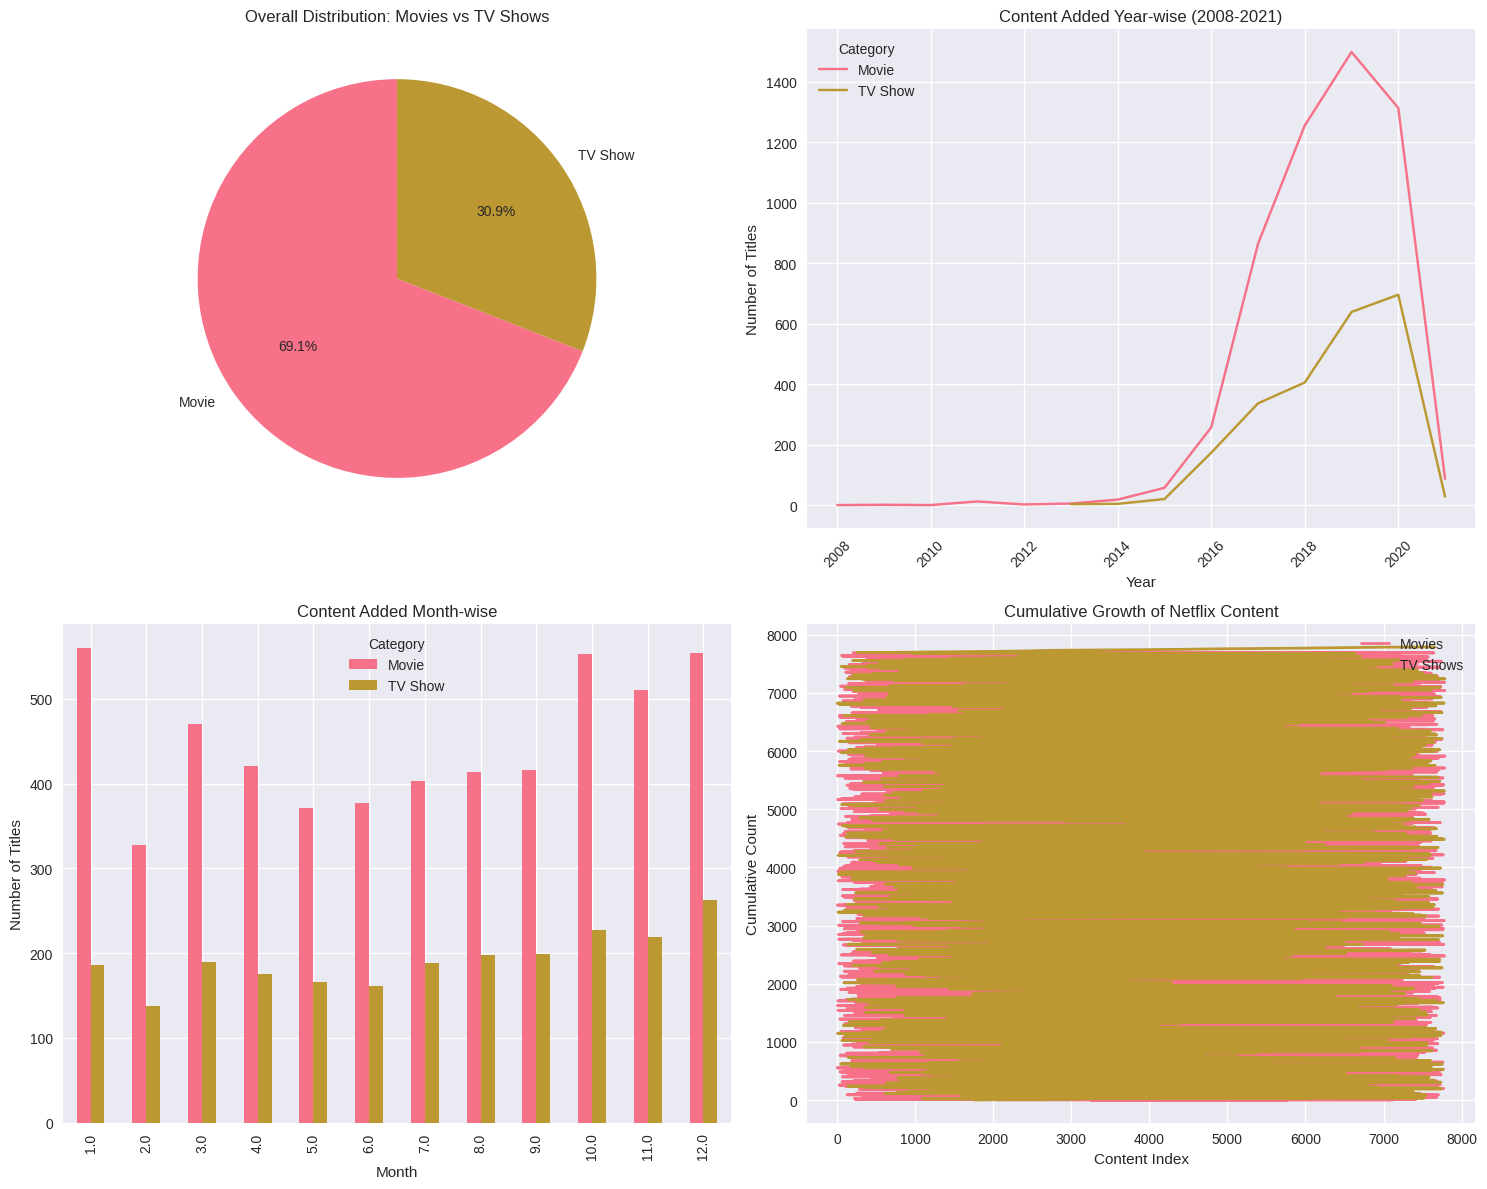

Content Distribution Summary:
Total Movies: 5379
Total TV Shows: 2410
Movie to TV Show ratio: 2.23:1


In [14]:
# 1. Overall distribution
plt.figure(figsize=(15, 12))

plt.subplot(2, 2, 1)
type_counts = netflix_df['Category'].value_counts()
plt.pie(type_counts.values, labels=type_counts.index, autopct='%1.1f%%', startangle=90)
plt.title('Overall Distribution: Movies vs TV Shows')

# 2. Year-wise distribution
plt.subplot(2, 2, 2)
yearly_content = netflix_df.groupby(['year_added', 'Category']).size().unstack()
yearly_content.plot(kind='line', ax=plt.gca())
plt.title('Content Added Year-wise (2008-2021)')
plt.xlabel('Year')
plt.ylabel('Number of Titles')
plt.legend(title='Category')
plt.xticks(rotation=45)

# 3. Monthly distribution
plt.subplot(2, 2, 3)
monthly_content = netflix_df.groupby(['month_added', 'Category']).size().unstack()
monthly_content.plot(kind='bar', ax=plt.gca())
plt.title('Content Added Month-wise')
plt.xlabel('Month')
plt.ylabel('Number of Titles')
plt.legend(title='Category')

# 4. Cumulative growth
plt.subplot(2, 2, 4)
netflix_df_sorted = netflix_df.sort_values('date_added')
netflix_df_sorted['cumulative_count'] = range(1, len(netflix_df_sorted) + 1)
movies_cumulative = netflix_df_sorted[netflix_df_sorted['Category'] == 'Movie']['cumulative_count']
tv_cumulative = netflix_df_sorted[netflix_df_sorted['Category'] == 'TV Show']['cumulative_count']

plt.plot(movies_cumulative.index, movies_cumulative.values, label='Movies', linewidth=2)
plt.plot(tv_cumulative.index, tv_cumulative.values, label='TV Shows', linewidth=2)
plt.title('Cumulative Growth of Netflix Content')
plt.xlabel('Content Index')
plt.ylabel('Cumulative Count')
plt.legend()

plt.tight_layout()
plt.show()

# Print summary statistics
print("Content Distribution Summary:")
print(f"Total Movies: {type_counts.get('Movie', 0)}")
print(f"Total TV Shows: {type_counts.get('TV Show', 0)}")
print(f"Movie to TV Show ratio: {type_counts.get('Movie', 0)/type_counts.get('TV Show', 0):.2f}:1")

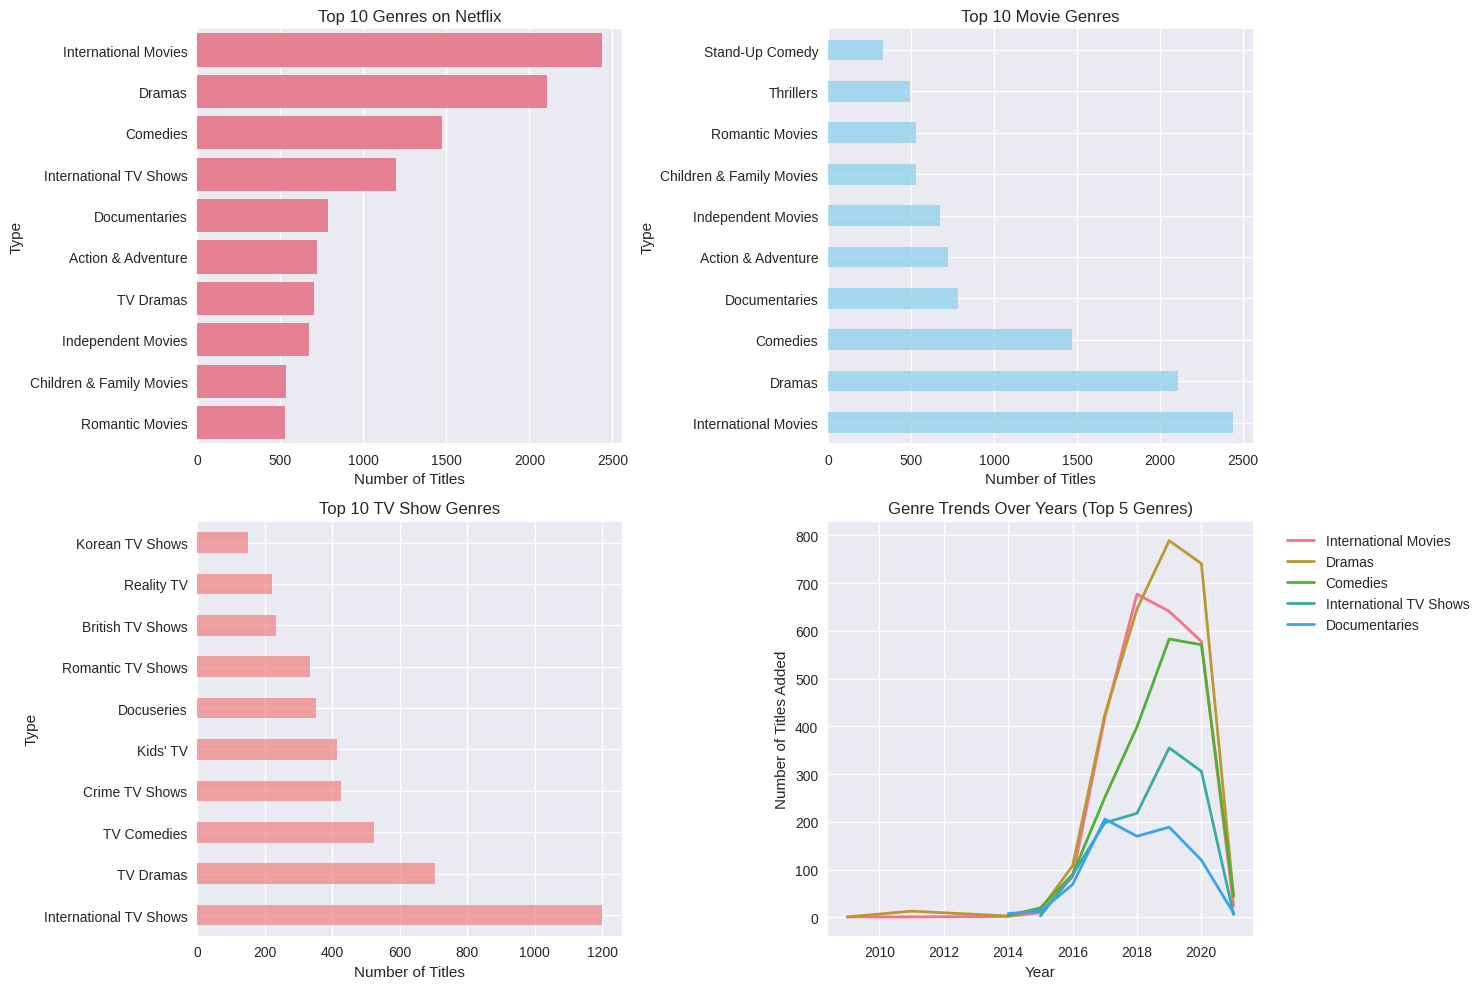

Genre Analysis Summary:
Total unique genres: 42
Top 5 genres: ['International Movies', 'Dramas', 'Comedies', 'International TV Shows', 'Documentaries']


In [16]:
# Genre analysis function
def analyze_genres(df):
    # Split listed_in column which contains multiple genres
    genres = df['Type'].str.split(', ').explode()
    genre_counts = genres.value_counts()

    return genre_counts

# Analyze genres for all content
all_genres = analyze_genres(netflix_df)

plt.figure(figsize=(15, 10))

# Top genres overall
plt.subplot(2, 2, 1)
top_genres = all_genres.head(10)
sns.barplot(y=top_genres.index, x=top_genres.values)
plt.title('Top 10 Genres on Netflix')
plt.xlabel('Number of Titles')

# Genre distribution by type
plt.subplot(2, 2, 2)
movie_genres = analyze_genres(netflix_df[netflix_df['Category'] == 'Movie']).head(10)
tv_genres = analyze_genres(netflix_df[netflix_df['Category'] == 'TV Show']).head(10)

movie_genres.head(10).plot(kind='barh', ax=plt.gca(), color='skyblue', alpha=0.7, label='Movies')
plt.title('Top 10 Movie Genres')
plt.xlabel('Number of Titles')

plt.subplot(2, 2, 3)
tv_genres.head(10).plot(kind='barh', ax=plt.gca(), color='lightcoral', alpha=0.7)
plt.title('Top 10 TV Show Genres')
plt.xlabel('Number of Titles')

# Genre trends over years
plt.subplot(2, 2, 4)
# Select top 5 genres for trend analysis
top_5_genres = all_genres.head(5).index.tolist()

# Create year-genre matrix
genre_trends = pd.DataFrame()
for genre in top_5_genres:
    genre_df = netflix_df[netflix_df['Type'].str.contains(genre, na=False)]
    yearly_genre = genre_df.groupby('year_added').size()
    genre_trends[genre] = yearly_genre

genre_trends.plot(kind='line', ax=plt.gca(), linewidth=2)
plt.title('Genre Trends Over Years (Top 5 Genres)')
plt.xlabel('Year')
plt.ylabel('Number of Titles Added')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()

print("Genre Analysis Summary:")
print(f"Total unique genres: {len(all_genres)}")
print(f"Top 5 genres: {list(all_genres.head(5).index)}")

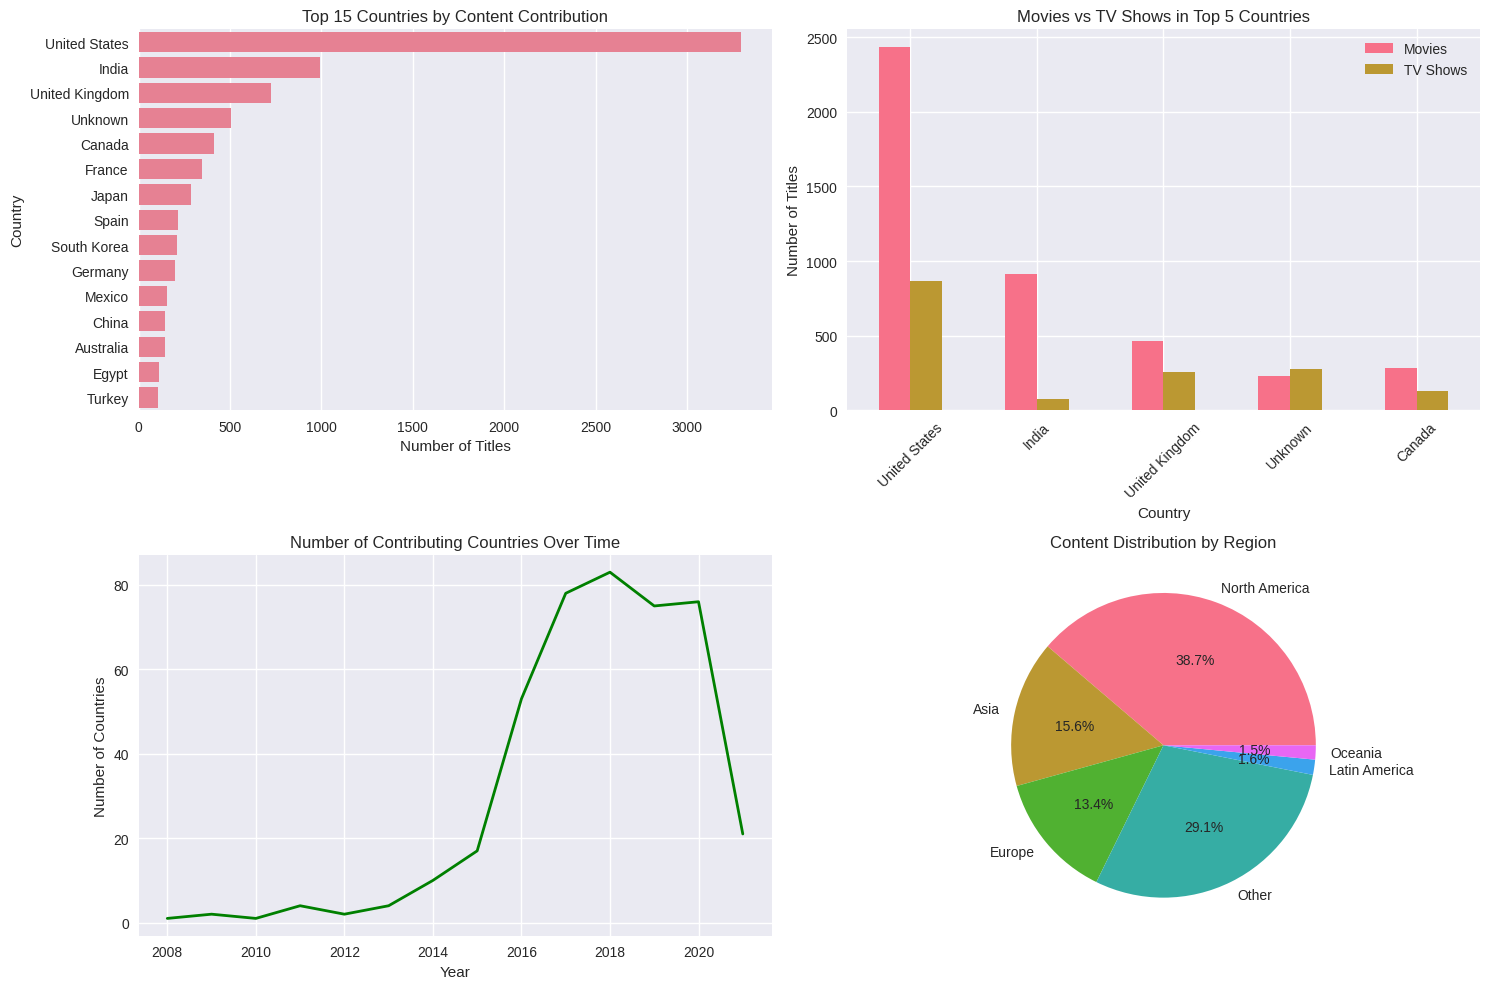

Country Analysis Summary:
Total countries represented: 122
Top 5 contributing countries: ['United States', 'India', 'United Kingdom', 'Unknown', 'Canada']


In [18]:
# Country analysis
def analyze_countries(df):
    countries = df['Country'].str.split(', ').explode()
    country_counts = countries.value_counts()
    return country_counts

country_contributions = analyze_countries(netflix_df)

plt.figure(figsize=(15, 10))

# Top countries
plt.subplot(2, 2, 1)
top_countries = country_contributions.head(15)
sns.barplot(y=top_countries.index, x=top_countries.values)
plt.title('Top 15 Countries by Content Contribution')
plt.xlabel('Number of Titles')

# Content type by top countries
plt.subplot(2, 2, 2)
top_5_countries = country_contributions.head(5).index
country_type_data = []

for country in top_5_countries:
    country_df = netflix_df[netflix_df['Country'].str.contains(country, na=False)]
    movies = len(country_df[country_df['Category'] == 'Movie'])
    tv_shows = len(country_df[country_df['Category'] == 'TV Show'])
    country_type_data.append([country, movies, tv_shows])

country_type_df = pd.DataFrame(country_type_data, columns=['Country', 'Movies', 'TV Shows'])
country_type_df.set_index('Country', inplace=True)
country_type_df.plot(kind='bar', ax=plt.gca())
plt.title('Movies vs TV Shows in Top 5 Countries')
plt.ylabel('Number of Titles')
plt.xticks(rotation=45)

# Geographic diversity over time
plt.subplot(2, 2, 3)
# Calculate number of unique countries per year
countries_per_year = netflix_df.groupby('year_added')['Country'].apply(
    lambda x: len(set([country for countries in x.dropna() for country in countries.split(', ')]))
)
countries_per_year.plot(kind='line', ax=plt.gca(), color='green', linewidth=2)
plt.title('Number of Contributing Countries Over Time')
plt.xlabel('Year')
plt.ylabel('Number of Countries')

# Regional analysis (grouping countries by continent)
plt.subplot(2, 2, 4)
# Simple regional grouping (you can enhance this)
regional_mapping = {
    'United States': 'North America',
    'India': 'Asia',
    'United Kingdom': 'Europe',
    'Canada': 'North America',
    'France': 'Europe',
    'Japan': 'Asia',
    'South Korea': 'Asia',
    'Spain': 'Europe',
    'Mexico': 'Latin America',
    'Australia': 'Oceania'
}

regional_data = {}
for country, count in country_contributions.items():
    region = regional_mapping.get(country, 'Other')
    regional_data[region] = regional_data.get(region, 0) + count

regional_df = pd.Series(regional_data)
regional_df.plot(kind='pie', autopct='%1.1f%%', ax=plt.gca())
plt.title('Content Distribution by Region')
plt.ylabel('')

plt.tight_layout()
plt.show()

print("Country Analysis Summary:")
print(f"Total countries represented: {len(country_contributions)}")
print(f"Top 5 contributing countries: {list(country_contributions.head(5).index)}")

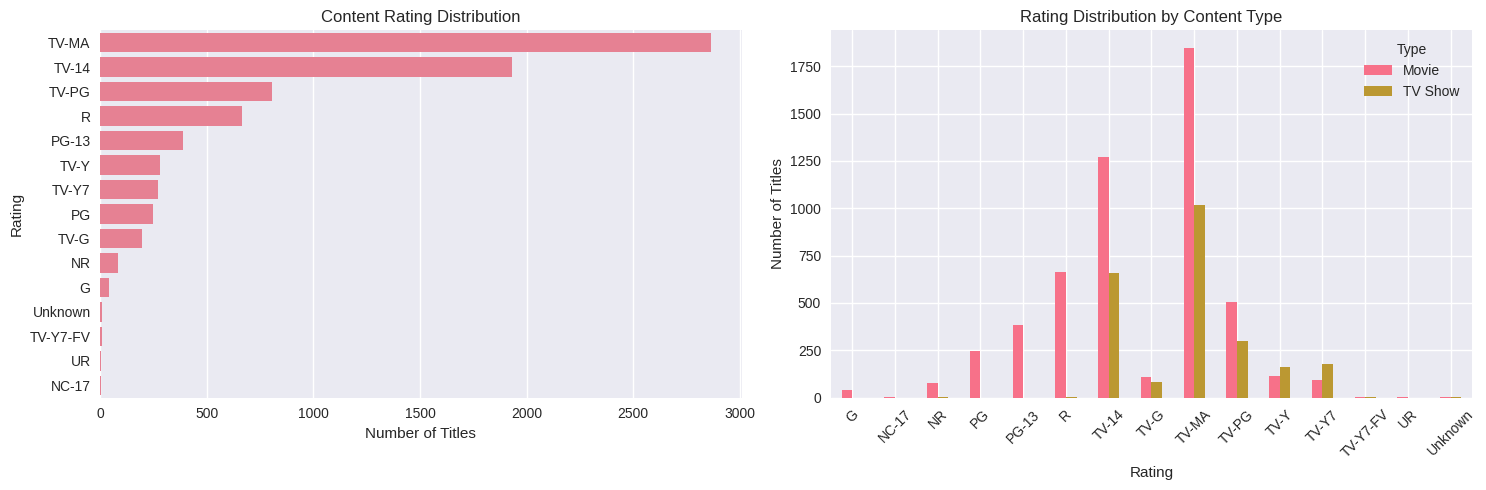

In [20]:
# Rating distribution
plt.figure(figsize=(15, 5))

plt.subplot(1, 2, 1)
rating_counts = netflix_df['Rating'].value_counts()
sns.barplot(y=rating_counts.index, x=rating_counts.values)
plt.title('Content Rating Distribution')
plt.xlabel('Number of Titles')

plt.subplot(1, 2, 2)
rating_by_type = pd.crosstab(netflix_df['Rating'], netflix_df['Category'])
rating_by_type.plot(kind='bar', ax=plt.gca())
plt.title('Rating Distribution by Content Type')
plt.xlabel('Rating')
plt.ylabel('Number of Titles')
plt.legend(title='Type')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [22]:
# Generate strategic insights
print("="*60)
print("STRATEGIC INSIGHTS AND RECOMMENDATIONS")
print("="*60)

# Insight 1: Content Type Strategy
movie_ratio = len(netflix_df[netflix_df['Category'] == 'Movie']) / len(netflix_df)
print(f"\n1. CONTENT TYPE STRATEGY:")
print(f"   • Current Movie/TV Show ratio: {movie_ratio:.1%} Movies")
print(f"   • Recommendation: {'Increase TV Show production' if movie_ratio > 0.7 else 'Maintain balanced approach'}")

# Insight 2: Genre Opportunities
underrepresented_genres = all_genres[all_genres < all_genres.median()].head(5)
print(f"\n2. GENRE OPPORTUNITIES:")
print(f"   • Underrepresented genres with growth potential: {list(underrepresented_genres.index)}")

# Insight 3: Geographic Expansion
top_countries_ratio = country_contributions.head(5).sum() / country_contributions.sum()
print(f"\n3. GEOGRAPHIC DIVERSITY:")
print(f"   • Top 5 countries contribute {top_countries_ratio:.1%} of total content")
print(f"   • Opportunity: Expand content from underrepresented regions")

# Insight 4: Recent Trends (last 3 years)
recent_years = netflix_df[netflix_df['year_added'] >= 2019]
if not recent_years.empty:
    recent_genres = analyze_genres(recent_years).head(3)
    print(f"\n4. RECENT TRENDS (2019-2021):")
    print(f"   • Top growing genres: {list(recent_genres.index)}")

    # Growth rate calculation
    recent_movies = len(recent_years[recent_years['Category'] == 'Movie'])
    recent_tv = len(recent_years[recent_years['Category'] == 'TV Show'])
    print(f"   • Recent content mix: {recent_movies/(recent_movies+recent_tv):.1%} Movies, {recent_tv/(recent_movies+recent_tv):.1%} TV Shows")

# Insight 5: Content Duration Analysis
print(f"\n5. CONTENT DURATION INSIGHTS:")
movie_durations = netflix_df[netflix_df['Category'] == 'Movie']['Duration'].str.extract('(\d+)').dropna().astype(int)
if not movie_durations.empty:
    avg_duration = movie_durations[0].mean()
    print(f"   • Average movie duration: {avg_duration:.0f} minutes")
    print(f"   • Recommendation: Consider producing content in popular duration ranges (90-120 mins)")

print("\n" + "="*60)

STRATEGIC INSIGHTS AND RECOMMENDATIONS

1. CONTENT TYPE STRATEGY:
   • Current Movie/TV Show ratio: 69.1% Movies
   • Recommendation: Maintain balanced approach

2. GENRE OPPORTUNITIES:
   • Underrepresented genres with growth potential: ['Sci-Fi & Fantasy', 'Sports Movies', 'Korean TV Shows', 'TV Action & Adventure', 'Anime Series']

3. GEOGRAPHIC DIVERSITY:
   • Top 5 countries contribute 61.9% of total content
   • Opportunity: Expand content from underrepresented regions

4. RECENT TRENDS (2019-2021):
   • Top growing genres: ['International Movies', 'Dramas', 'Comedies']
   • Recent content mix: 68.0% Movies, 32.0% TV Shows

5. CONTENT DURATION INSIGHTS:
   • Average movie duration: 99 minutes
   • Recommendation: Consider producing content in popular duration ranges (90-120 mins)



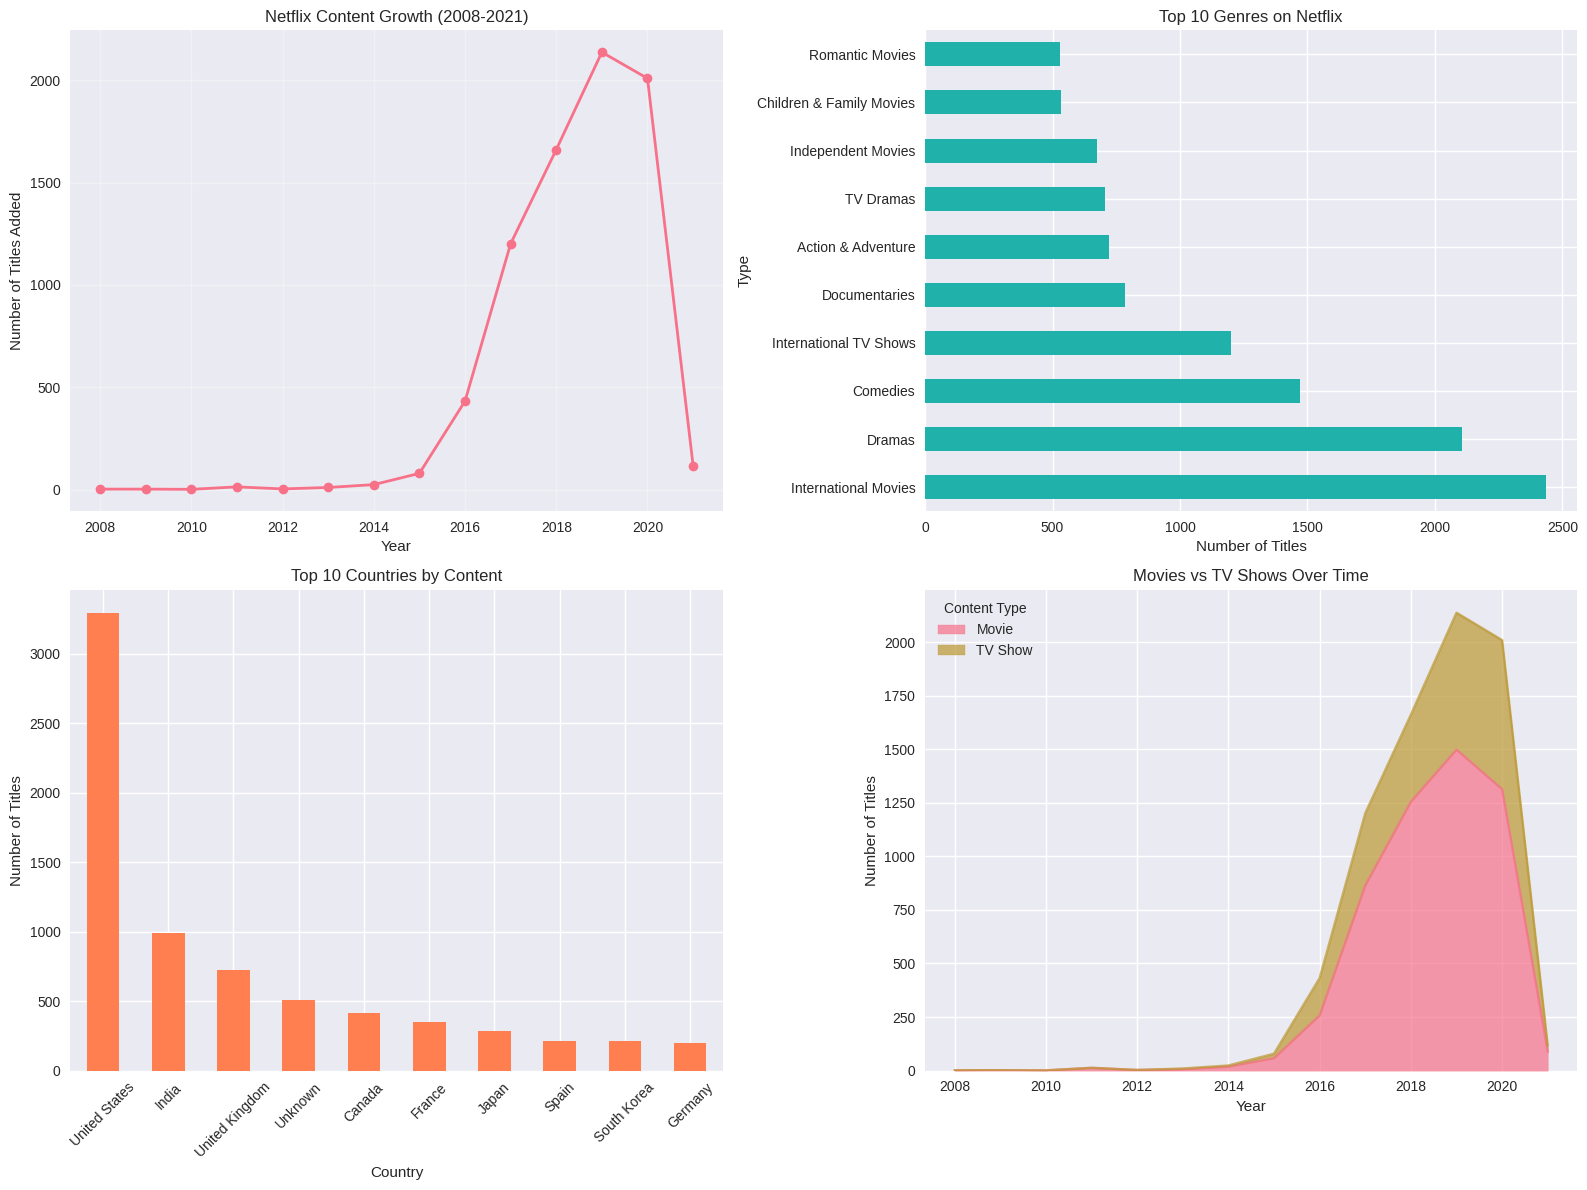


NETFLIX DATA ANALYSIS PROJECT SUMMARY STATISTICS
Total Titles Analyzed: 7789
Time Period: 2008.0 - 2021.0
Movies: 5379 (69.1%)
TV Shows: 2410 (30.9%)
Countries Represented: 122
Unique Genres: 42


In [27]:
# Create a comprehensive summary dashboard
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Content Growth Over Time
yearly_totals = netflix_df['year_added'].value_counts().sort_index()
axes[0,0].plot(yearly_totals.index, yearly_totals.values, marker='o', linewidth=2)
axes[0,0].set_title('Netflix Content Growth (2008-2021)')
axes[0,0].set_xlabel('Year')
axes[0,0].set_ylabel('Number of Titles Added')
axes[0,0].grid(True, alpha=0.3)

# 2. Top 10 Genres
all_genres.head(10).plot(kind='barh', ax=axes[0,1], color='lightseagreen')
axes[0,1].set_title('Top 10 Genres on Netflix')
axes[0,1].set_xlabel('Number of Titles')

# 3. Geographic Distribution
country_contributions.head(10).plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Top 10 Countries by Content')
axes[1,0].set_xlabel('Country')
axes[1,0].set_ylabel('Number of Titles')
axes[1,0].tick_params(axis='x', rotation=45)

# 4. Content Type Evolution
yearly_content.plot(kind='area', ax=axes[1,1], alpha=0.7)
axes[1,1].set_title('Movies vs TV Shows Over Time')
axes[1,1].set_xlabel('Year')
axes[1,1].set_ylabel('Number of Titles')
axes[1,1].legend(title='Content Type')

plt.tight_layout()
plt.show()

# Final summary statistics
print("\n" + "="*50)
print("NETFLIX DATA ANALYSIS PROJECT SUMMARY STATISTICS")
print("="*50)
print(f"Total Titles Analyzed: {len(netflix_df)}")
print(f"Time Period: {netflix_df['year_added'].min()} - {netflix_df['year_added'].max()}")
print(f"Movies: {len(netflix_df[netflix_df['Category'] == 'Movie'])} ({len(netflix_df[netflix_df['Category'] == 'Movie'])/len(netflix_df)*100:.1f}%)")
print(f"TV Shows: {len(netflix_df[netflix_df['Category'] == 'TV Show'])} ({len(netflix_df[netflix_df['Category'] == 'TV Show'])/len(netflix_df)*100:.1f}%)")
print(f"Countries Represented: {len(country_contributions)}")
print(f"Unique Genres: {len(all_genres)}")
print("="*50)